---
title: "4 - Proyecto de ML"
toc: true
---

::: {.callout-note}
## Atribución
Este apunte es una traducción y leve adaptación de la notebook [`02_end_to_end_machine_learning_project.ipynb`](https://github.com/ageron/handson-mlp/blob/main/02_end_to_end_machine_learning_project.ipynb) del repositorio [`ageron/handson-mlp`](https://github.com/ageron/handson-mlp), de Aurélien Géron. El material original se distribuye bajo la licencia [Apache License 2.0](https://github.com/ageron/handson-mlp/blob/main/LICENSE). 
Esta versión explicita que fue traducida y adaptada para este curso.
:::

Requiere Scikit-Learn ≥ 1.6.1:

In [1]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

# Obtener los datos

Su tarea es predecir el valor mediano de las viviendas en distritos de California a partir de varias características de esos distritos.

## Descargar los datos

In [2]:
from pathlib import Path
import polars as pl
import tarfile
import urllib.request


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pl.read_csv(Path("datasets/housing/housing.csv"))


housing_full = load_housing_data()

## Dar un vistazo rápido a la estructura de los datos

In [3]:
housing_full.head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,f64,str
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,"""NEAR BAY"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,"""NEAR BAY"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,"""NEAR BAY"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,"""NEAR BAY"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,"""NEAR BAY"""


In [4]:
housing_full.glimpse()

Rows: 20640
Columns: 10
$ longitude          <f64> -122.23, -122.22, -122.24, -122.25, -122.25, -122.25, -122.25, -122.25, -122.26, -122.25
$ latitude           <f64> 37.88, 37.86, 37.85, 37.85, 37.85, 37.85, 37.84, 37.84, 37.84, 37.84
$ housing_median_age <f64> 41.0, 21.0, 52.0, 52.0, 52.0, 52.0, 52.0, 52.0, 42.0, 52.0
$ total_rooms        <f64> 880.0, 7099.0, 1467.0, 1274.0, 1627.0, 919.0, 2535.0, 3104.0, 2555.0, 3549.0
$ total_bedrooms     <f64> 129.0, 1106.0, 190.0, 235.0, 280.0, 213.0, 489.0, 687.0, 665.0, 707.0
$ population         <f64> 322.0, 2401.0, 496.0, 558.0, 565.0, 413.0, 1094.0, 1157.0, 1206.0, 1551.0
$ households         <f64> 126.0, 1138.0, 177.0, 219.0, 259.0, 193.0, 514.0, 647.0, 595.0, 714.0
$ median_income      <f64> 8.3252, 8.3014, 7.2574, 5.6431, 3.8462, 4.0368, 3.6591, 3.12, 2.0804, 3.6912
$ median_house_value <f64> 452600.0, 358500.0, 352100.0, 341300.0, 342200.0, 269700.0, 299200.0, 241400.0, 226700.0, 261100.0
$ ocean_proximity    <str> 'NEAR BAY', 'NEAR BAY'

In [5]:
housing_full["ocean_proximity"].value_counts().sort("ocean_proximity")

ocean_proximity,count
str,u32
"""<1H OCEAN""",9136
"""INLAND""",6551
"""ISLAND""",5
"""NEAR BAY""",2290
"""NEAR OCEAN""",2658


In [6]:
housing_full.describe()

statistic,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0,"""20640"""
"""null_count""",0.0,0.0,0.0,0.0,207.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.53968,3.870671,206855.816909,null
"""std""",2.003532,2.135952,12.585558,2181.615252,421.38507,1132.462122,382.329753,1.899822,115395.615874,null
"""min""",-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,"""<1H OCEAN"""
"""25%""",-121.8,33.93,18.0,1448.0,296.0,787.0,280.0,2.5637,119600.0,null
"""50%""",-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5349,179700.0,null
"""75%""",-118.01,37.71,37.0,3148.0,647.0,1725.0,605.0,4.7431,264700.0,null
"""max""",-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,"""NEAR OCEAN"""


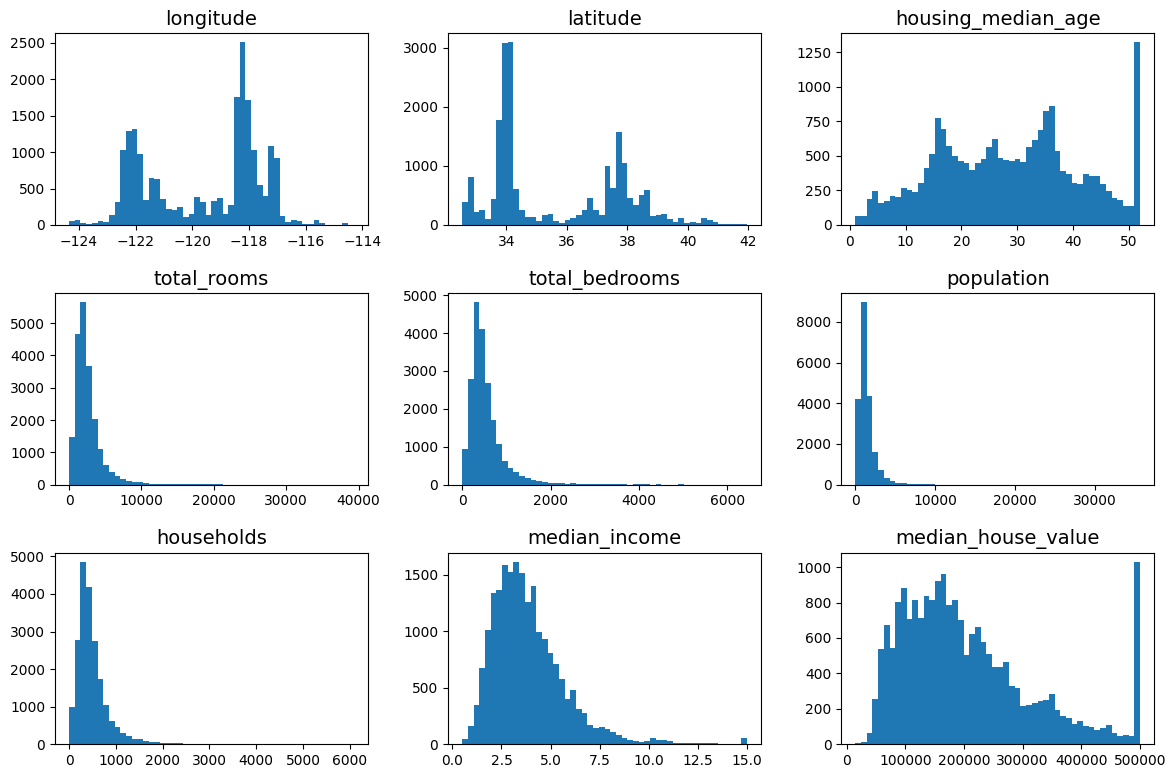

In [7]:
import matplotlib.pyplot as plt

# código extra – las siguientes 5 líneas definen los tamaños de fuente por defecto
plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)


def to_numpy(values):
    return values.to_numpy() if hasattr(values, "to_numpy") else values

def take_rows(data, indices):
    return (
        data.with_row_index("__row_idx")
        .filter(pl.col("__row_idx").is_in(indices))
        .drop("__row_idx")
    )

def plot_scatter(
    df,
    x,
    y,
    *,
    alpha=1.0,
    s=None,
    c=None,
    cmap=None,
    colorbar=False,
    label=None,
    figsize=(8, 6),
    grid=True,
):
    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(
        to_numpy(df[x]),
        to_numpy(df[y]),
        alpha=alpha,
        s=to_numpy(s) if s is not None else None,
        c=to_numpy(c) if c is not None else None,
        cmap=cmap,
        label=label,
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(grid)
    if colorbar:
        plt.colorbar(scatter, ax=ax)
    if label is not None:
        ax.legend()
    return ax


def plot_scatter_matrix(df, columns, figsize=(12, 8)):
    n = len(columns)
    fig, axs = plt.subplots(n, n, figsize=figsize)

    for i, y_col in enumerate(columns):
        y = df[y_col].drop_nulls().to_numpy()
        for j, x_col in enumerate(columns):
            ax = axs[i, j]
            x = df[x_col].drop_nulls().to_numpy()
            if i == j:
                ax.hist(x, bins=30, color="0.7")
            else:
                ax.scatter(df[x_col].to_numpy(), df[y_col].to_numpy(), s=5, alpha=0.2)

            if i == n - 1:
                ax.set_xlabel(x_col)
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(y_col)
            else:
                ax.set_yticklabels([])

    plt.tight_layout()

numeric_columns = housing_full.select(pl.selectors.numeric()).columns
fig, axs = plt.subplots(3, 3, figsize=(12, 8))

for ax, column in zip(axs.flat, numeric_columns):
    ax.hist(housing_full[column].drop_nulls().to_numpy(), bins=50)
    ax.set_title(column)

for ax in axs.flat[len(numeric_columns) :]:
    ax.remove()

plt.tight_layout();

## Crear un conjunto de prueba

In [8]:
import numpy as np

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return take_rows(data, train_indices), take_rows(data, test_indices)

Para garantizar que las salidas de este notebook sean las mismas cada vez que lo ejecutamos, debemos fijar la semilla aleatoria:

In [9]:
rng = np.random.default_rng(seed=42)
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)
len(train_set)

16512

In [10]:
len(test_set)

4128

Lamentablemente, esto no garantiza que este notebook produzca exactamente los mismos resultados que en el libro, ya que existen otras posibles fuentes de variación. La más importante es que los algoritmos se ajustan con el tiempo a medida que evolucionan las bibliotecas. Así que tolere algunas diferencias menores: idealmente, la mayoría de las salidas deberían ser iguales o, al menos, estar en el rango esperado.

Nota: otra fuente de aleatoriedad es el orden de los `set` de Python. Depende de la función `hash()`, que recibe una "sal" aleatoria cuando Python arranca (esto comenzó en Python 3.3 para prevenir ciertos ataques de denegación de servicio). Para eliminar esta aleatoriedad, la solución es configurar la variable de entorno `PYTHONHASHSEED` en `"0"` _antes_ de que Python se inicie. Si lo hace después, no ocurrirá nada. Por suerte, si está ejecutando este notebook en Colab, esa variable ya viene configurada.

In [11]:
from zlib import crc32


def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32


def split_data_with_id_hash(data, test_ratio, id_column):
    in_test_set = pl.Series(
        "in_test_set",
        [is_id_in_test_set(id_, test_ratio) for id_ in data[id_column].to_list()],
    )
    return data.filter(~in_test_set), data.filter(in_test_set)

In [12]:
housing_with_id = housing_full.with_row_index("index")  # agrega una columna `index`
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [13]:
housing_with_id = housing_with_id.with_columns(
    (pl.col("longitude") * 1000 + pl.col("latitude")).alias("id")
)
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [14]:
from sklearn.model_selection import train_test_split

def sklearn_split_polars(data, *, test_size, random_state, stratify=None):
    indices = np.arange(len(data))
    stratify_values = None if stratify is None else data[stratify].to_numpy()
    train_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values,
    )
    return take_rows(data, train_indices), take_rows(data, test_indices)


train_set, test_set = sklearn_split_polars(
    housing_full, test_size=0.2, random_state=42
)

In [15]:
test_set["total_bedrooms"].is_null().sum()

44

In [16]:
housing_full = housing_full.with_columns(
    pl.when(pl.col("median_income") < 1.5)
    .then(1)
    .when(pl.col("median_income") < 3.0)
    .then(2)
    .when(pl.col("median_income") < 4.5)
    .then(3)
    .when(pl.col("median_income") < 6.0)
    .then(4)
    .otherwise(5)
    .alias("income_cat")
)

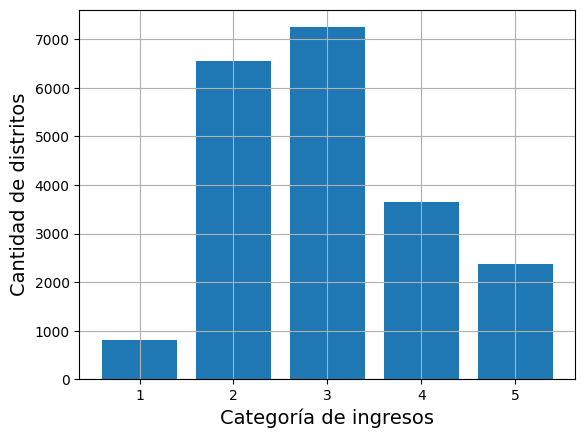

In [17]:
cat_counts = housing_full.group_by("income_cat").len().sort("income_cat")
plt.bar(cat_counts["income_cat"].to_list(), cat_counts["len"].to_list())
plt.grid(True)
plt.xlabel("Categoría de ingresos")
plt.ylabel("Cantidad de distritos");

In [18]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(
    np.zeros(len(housing_full)), housing_full["income_cat"].to_numpy()
):
    strat_train_set_n = take_rows(housing_full, train_index)
    strat_test_set_n = take_rows(housing_full, test_index)
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [19]:
strat_train_set, strat_test_set = strat_splits[0]

Es mucho más corto obtener una única partición estratificada:

In [20]:
strat_train_set, strat_test_set = sklearn_split_polars(
    housing_full, test_size=0.2, random_state=42, stratify="income_cat"
)

In [21]:
(
    strat_test_set.group_by("income_cat")
    .len()
    .sort("income_cat")
    .with_columns((pl.col("len") / len(strat_test_set)).alias("proportion"))
    .select("income_cat", "proportion")
)

income_cat,proportion
i32,f64
1,0.039486
2,0.317345
3,0.35126
4,0.176841
5,0.115068


In [22]:
# código extra – calcula los datos de la Figura 2–10
def income_cat_proportions(data):
    return (
        data.group_by("income_cat")
        .len()
        .sort("income_cat")
        .with_columns((pl.col("len") / len(data)).alias("proportion"))
        .select("income_cat", "proportion")
    )


train_set, test_set = sklearn_split_polars(housing_full, test_size=0.2, random_state=42)

compare_props = (
    income_cat_proportions(housing_full)
    .rename({"proportion": "General %"})
    .join(
        income_cat_proportions(strat_test_set).rename(
            {"proportion": "Estratificado %"}
        ),
        on="income_cat",
    )
    .join(
        income_cat_proportions(test_set).rename({"proportion": "Aleatorio %"}),
        on="income_cat",
    )
    .with_columns(
        (
            pl.col("Estratificado %") / pl.col("General %") - 1
        ).alias("Error estrat. %"),
        (pl.col("Aleatorio %") / pl.col("General %") - 1).alias("Error aleat. %"),
    )
)
compare_props.with_columns(pl.exclude("income_cat") * 100).with_columns(pl.selectors.numeric().round(2))

income_cat,General %,Estratificado %,Aleatorio %,Error estrat. %,Error aleat. %
i32,f64,f64,f64,f64,f64
1,3.95,3.95,4.24,0.0,7.36
2,31.73,31.73,30.64,0.0,-3.44
3,35.13,35.13,34.5,0.0,-1.79
4,17.69,17.68,18.51,-0.05,4.6
5,11.5,11.51,12.11,0.08,5.35


In [23]:
strat_train_set = strat_train_set.drop("income_cat")
strat_test_set = strat_test_set.drop("income_cat")

# Explorar y visualizar los datos para obtener insights

In [24]:
housing = strat_train_set.clone()

## Visualización de datos geográficos

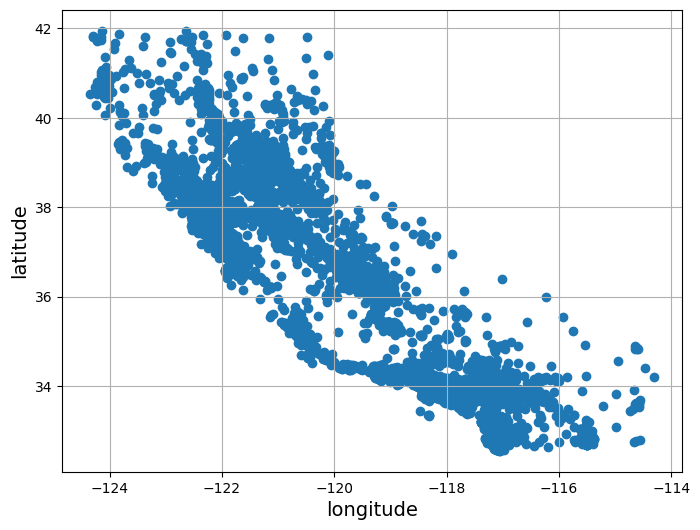

In [25]:
plot_scatter(housing, "longitude", "latitude", grid=True);

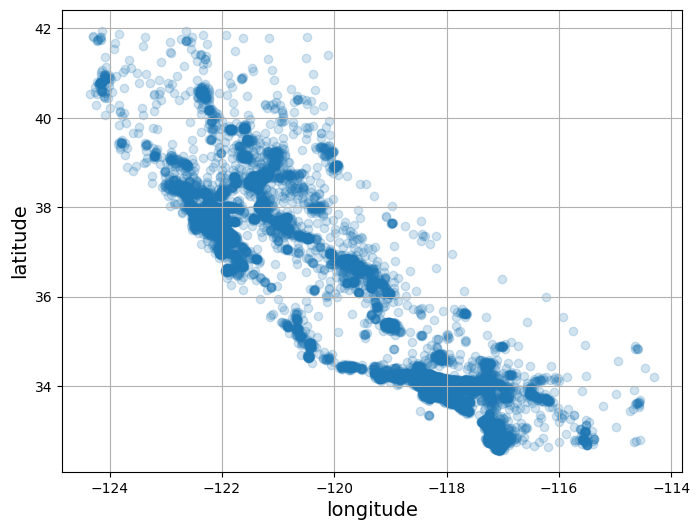

In [26]:
plot_scatter(housing, "longitude", "latitude", grid=True, alpha=0.2);

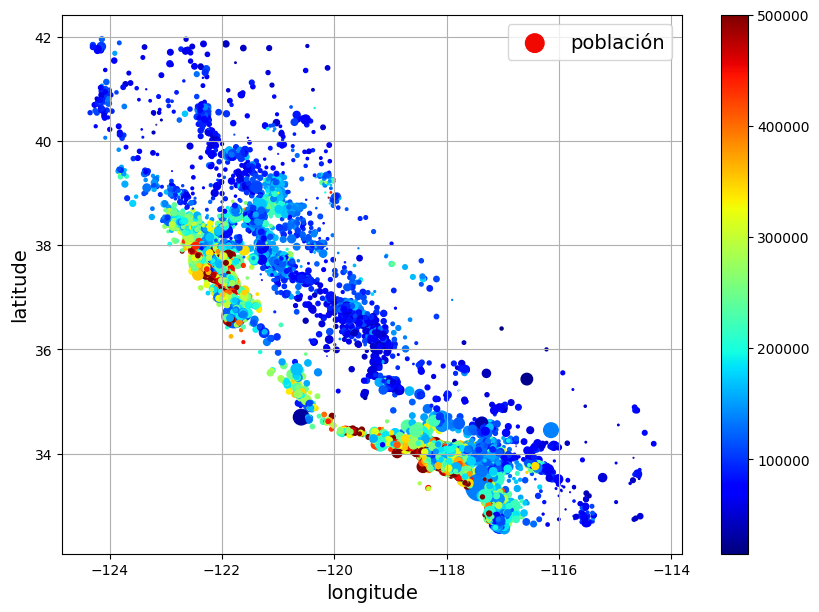

In [27]:
plot_scatter(
    housing,
    "longitude",
    "latitude",
    grid=True,
    s=housing["population"] / 100,
    label="población",
    c=housing["median_house_value"],
    cmap="jet",
    colorbar=True,
    figsize=(10, 7),
);

La siguiente celda genera la primera figura del capítulo (este código no está en el libro). Es simplemente una versión mejorada de la figura anterior, con una imagen de California agregada al fondo, etiquetas más agradables y sin grilla.

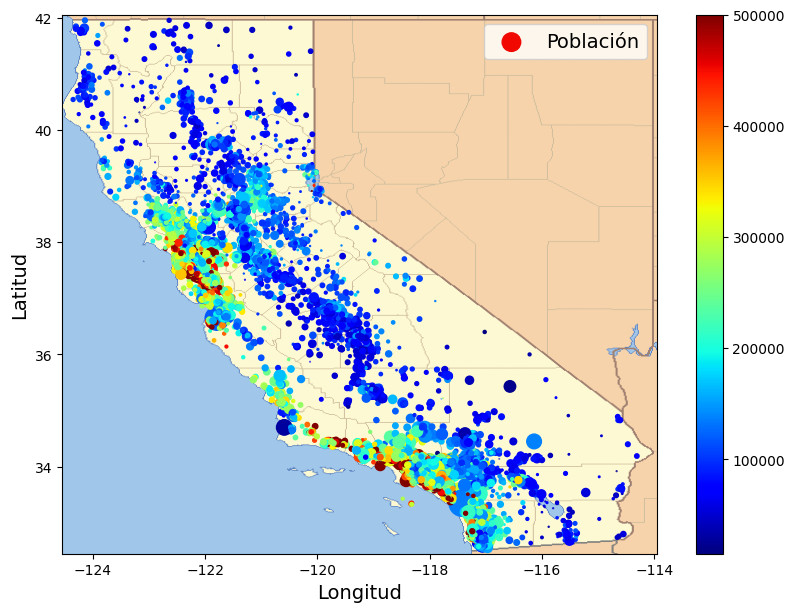

In [28]:
# Descargar la imagen de California
filename = "california.png"
filepath = Path(f"my_{filename}")
if not filepath.is_file():
    homlp_root = "https://github.com/ageron/handson-mlp/raw/main/"
    url = homlp_root + "images/end_to_end_project/" + filename
    print("Descargando", filename)
    urllib.request.urlretrieve(url, filepath)

housing_renamed = housing.rename(
    {
        "latitude": "Latitud",
        "longitude": "Longitud",
        "population": "Población",
        "median_house_value": "Valor mediano de la vivienda (ᴜsᴅ)",
    }
)
plot_scatter(
    housing_renamed,
    "Longitud",
    "Latitud",
    s=housing_renamed["Población"] / 100,
    label="Población",
    c=housing_renamed["Valor mediano de la vivienda (ᴜsᴅ)"],
    cmap="jet",
    colorbar=True,
    figsize=(10, 7),
    grid=False,
)

california_img = plt.imread(filepath)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis);

## Buscar correlaciones

In [29]:
corr_matrix = housing.select(pl.selectors.numeric()).corr()

In [30]:
pl.DataFrame(
    {
        "atributo": corr_matrix.columns,
        "median_house_value": corr_matrix["median_house_value"],
    }
).sort("median_house_value", descending=True)

atributo,median_house_value
str,f64
"""total_bedrooms""",NaN
"""median_house_value""",1.0
"""median_income""",0.687369
"""total_rooms""",0.132973
"""housing_median_age""",0.107244
"""households""",0.066395
"""population""",-0.025966
"""longitude""",-0.049937
"""latitude""",-0.14229


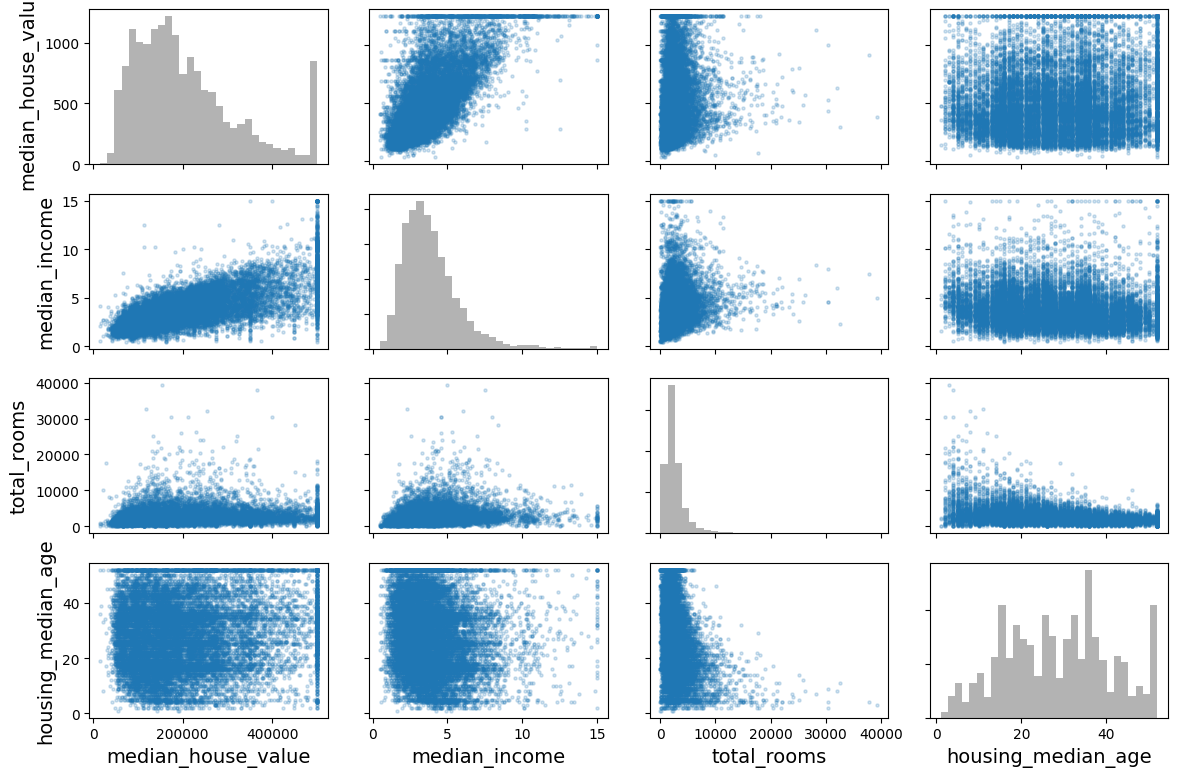

In [31]:
attributes = [
    "median_house_value",
    "median_income",
    "total_rooms",
    "housing_median_age",
]
plot_scatter_matrix(housing, attributes, figsize=(12, 8));

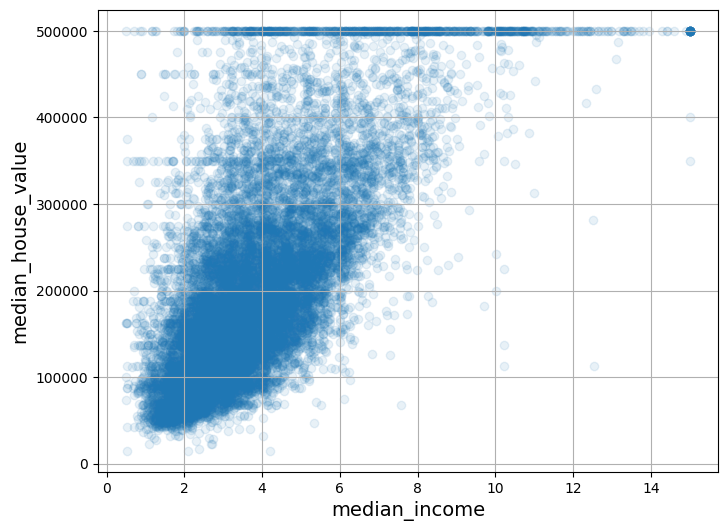

In [32]:
plot_scatter(
    housing,
    "median_income",
    "median_house_value",
    alpha=0.1,
    grid=True,
);

## Experimentar con combinaciones de atributos

In [33]:
housing = housing.with_columns(
    (pl.col("total_rooms") / pl.col("households")).alias("rooms_per_house"),
    (pl.col("total_bedrooms") / pl.col("total_rooms")).alias("bedrooms_ratio"),
    (pl.col("population") / pl.col("households")).alias("people_per_house"),
)

In [34]:
corr_matrix = housing.select(pl.selectors.numeric()).corr()
pl.DataFrame(
    {
        "atributo": corr_matrix.columns,
        "median_house_value": corr_matrix["median_house_value"],
    }
).sort("median_house_value", descending=True)

atributo,median_house_value
str,f64
"""total_bedrooms""",NaN
"""bedrooms_ratio""",NaN
"""median_house_value""",1.0
"""median_income""",0.687369
"""rooms_per_house""",0.151071
…,…
"""households""",0.066395
"""people_per_house""",-0.022334
"""population""",-0.025966


# Preparar los datos para algoritmos de Machine Learning

Volvamos al conjunto de entrenamiento original y separemos la variable objetivo (observe que `strat_train_set.drop()` crea una copia de `strat_train_set` sin la columna; no modifica realmente `strat_train_set`, a menos que pase `inplace=True`):

In [35]:
housing = strat_train_set.drop("median_house_value")
housing_labels = strat_train_set["median_house_value"].clone()

Nota: la celda anterior reinicia el dataframe `housing`, eliminando también los atributos personalizados que acabamos de agregar. Hacemos esto porque, más adelante en el capítulo, construiremos un `transformation pipeline` automatizado para manejar todos estos pasos de una sola vez.

## Limpieza de datos

En el libro se enumeran 3 opciones para manejar los valores NaN:

```python
housing = housing.drop_nulls(subset=["total_bedrooms"])  # opción 1

housing = housing.drop("total_bedrooms")  # opción 2

median = housing["total_bedrooms"].median()  # opción 3
housing = housing.with_columns(pl.col("total_bedrooms").fill_null(median))
```

Para cada opción, crearemos una copia de `housing` y trabajaremos sobre esa copia para evitar romper `housing`. También mostraremos la salida de cada opción, filtrando las filas que originalmente contenían un valor NaN.

In [36]:
housing_with_row_id = housing.with_row_index("row_id")
null_rows = housing_with_row_id.filter(
    pl.any_horizontal(pl.all().exclude("row_id").is_null())
)
null_row_ids = null_rows["row_id"]
null_rows.head()

row_id,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
u32,f64,f64,f64,f64,f64,f64,f64,f64,str
146,-118.27,34.04,13.0,1784.0,null,2158.0,682.0,1.7038,"""<1H OCEAN"""
263,-117.65,34.04,15.0,3393.0,null,2039.0,611.0,3.9336,"""INLAND"""
294,-122.5,37.75,44.0,1819.0,null,1137.0,354.0,3.4919,"""NEAR OCEAN"""
402,-114.59,34.83,41.0,812.0,null,375.0,158.0,1.7083,"""INLAND"""
411,-118.08,33.92,38.0,1335.0,null,1011.0,269.0,3.6908,"""<1H OCEAN"""


In [37]:
housing_option1 = housing_with_row_id.clone()

housing_option1 = housing_option1.drop_nulls(subset=["total_bedrooms"])  # opción 1

housing_option1.filter(pl.col("row_id").is_in(null_row_ids)).head()

/tmp/ipykernel_78080/2780181098.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  housing_option1.filter(pl.col("row_id").is_in(null_row_ids)).head()


row_id,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
u32,f64,f64,f64,f64,f64,f64,f64,f64,str


In [38]:
housing_option2 = housing_with_row_id.clone()

housing_option2 = housing_option2.drop("total_bedrooms")  # opción 2

housing_option2.filter(pl.col("row_id").is_in(null_row_ids)).head()

/tmp/ipykernel_78080/2687166581.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  housing_option2.filter(pl.col("row_id").is_in(null_row_ids)).head()


row_id,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
u32,f64,f64,f64,f64,f64,f64,f64,str
146,-118.27,34.04,13.0,1784.0,2158.0,682.0,1.7038,"""<1H OCEAN"""
263,-117.65,34.04,15.0,3393.0,2039.0,611.0,3.9336,"""INLAND"""
294,-122.5,37.75,44.0,1819.0,1137.0,354.0,3.4919,"""NEAR OCEAN"""
402,-114.59,34.83,41.0,812.0,375.0,158.0,1.7083,"""INLAND"""
411,-118.08,33.92,38.0,1335.0,1011.0,269.0,3.6908,"""<1H OCEAN"""


In [39]:
housing_option3 = housing_with_row_id.clone()

median = housing["total_bedrooms"].median()
housing_option3 = housing_option3.with_columns(
    pl.col("total_bedrooms").fill_null(median)
)  # opción 3

housing_option3.filter(pl.col("row_id").is_in(null_row_ids)).head()

/tmp/ipykernel_78080/3293165471.py:8: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  housing_option3.filter(pl.col("row_id").is_in(null_row_ids)).head()


row_id,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
u32,f64,f64,f64,f64,f64,f64,f64,f64,str
146,-118.27,34.04,13.0,1784.0,435.0,2158.0,682.0,1.7038,"""<1H OCEAN"""
263,-117.65,34.04,15.0,3393.0,435.0,2039.0,611.0,3.9336,"""INLAND"""
294,-122.5,37.75,44.0,1819.0,435.0,1137.0,354.0,3.4919,"""NEAR OCEAN"""
402,-114.59,34.83,41.0,812.0,435.0,375.0,158.0,1.7083,"""INLAND"""
411,-118.08,33.92,38.0,1335.0,435.0,1011.0,269.0,3.6908,"""<1H OCEAN"""


In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Separamos los atributos numéricos para usar la estrategia `"median"` (ya que no puede calcularse sobre atributos de texto como `ocean_proximity`):

In [41]:
housing_num = housing.select(pl.selectors.numeric())

In [42]:
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [43]:
imputer.statistics_

array([-118.5   ,   34.26  ,   29.    , 2126.5   ,  435.    , 1167.    ,
        410.    ,    3.5394])

Verifiquemos que esto sea lo mismo que calcular manualmente la mediana de cada atributo:

In [44]:
housing_num.median().to_numpy().ravel()

array([-118.5   ,   34.26  ,   29.    , 2126.5   ,  435.    , 1167.    ,
        410.    ,    3.5394])

Transformar el conjunto de entrenamiento:

In [45]:
X = imputer.transform(housing_num)

In [46]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [47]:
housing_tr = pl.DataFrame(X, schema=housing_num.columns)

In [48]:
(
    housing_tr.with_row_index("row_id")
    .filter(pl.col("row_id").is_in(null_row_ids))
    .drop("row_id")
    .head()
)

/tmp/ipykernel_78080/2377588852.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col("row_id").is_in(null_row_ids))


longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
f64,f64,f64,f64,f64,f64,f64,f64
-118.27,34.04,13.0,1784.0,435.0,2158.0,682.0,1.7038
-117.65,34.04,15.0,3393.0,435.0,2039.0,611.0,3.9336
-122.5,37.75,44.0,1819.0,435.0,1137.0,354.0,3.4919
-114.59,34.83,41.0,812.0,435.0,375.0,158.0,1.7083
-118.08,33.92,38.0,1335.0,435.0,1011.0,269.0,3.6908


In [49]:
imputer.strategy

'median'

In [50]:
housing_tr = pl.DataFrame(X, schema=housing_num.columns)

In [51]:
(
    housing_tr.with_row_index("row_id")
    .filter(pl.col("row_id").is_in(null_row_ids))
    .drop("row_id")
    .head()
)  # no se muestra en el libro

/tmp/ipykernel_78080/4069408708.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col("row_id").is_in(null_row_ids))


longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
f64,f64,f64,f64,f64,f64,f64,f64
-118.27,34.04,13.0,1784.0,435.0,2158.0,682.0,1.7038
-117.65,34.04,15.0,3393.0,435.0,2039.0,611.0,3.9336
-122.5,37.75,44.0,1819.0,435.0,1137.0,354.0,3.4919
-114.59,34.83,41.0,812.0,435.0,375.0,158.0,1.7083
-118.08,33.92,38.0,1335.0,435.0,1011.0,269.0,3.6908


In [52]:
# from sklearn import set_config
# set_config(transform_output="polars")

Ahora descartemos algunos outliers:

In [53]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

In [54]:
outlier_pred

array([-1, -1,  1, ...,  1,  1,  1], shape=(16512,))

Si quisiera eliminar outliers, ejecutaría el siguiente código:

In [55]:
# housing = housing.filter(pl.Series("is_inlier", outlier_pred == 1))
# housing_labels = housing_labels.filter(pl.Series("is_inlier", outlier_pred == 1))

## Manejo de atributos de texto y categóricos

Ahora preprocesemos la variable de entrada categórica `ocean_proximity`:

In [56]:
housing_cat = housing.select("ocean_proximity")
housing_cat.head(8)

ocean_proximity
str
"""NEAR BAY"""
"""NEAR BAY"""
"""NEAR BAY"""
"""NEAR BAY"""
"""NEAR BAY"""
"""NEAR BAY"""
"""NEAR BAY"""
"""NEAR BAY"""


In [57]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [58]:
housing_cat_encoded[:8]

array([[3.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.]])

In [59]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [60]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [61]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

Por defecto, la clase `OneHotEncoder` devuelve un arreglo disperso (`sparse`), pero podemos convertirlo en un arreglo denso si hace falta llamando al método `toarray()`:

In [62]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

Como alternativa, puede establecer `sparse_output=False` al crear el `OneHotEncoder` (nota: el hiperparámetro `sparse` pasó a llamarse `sparse_output` en Scikit-Learn 1.2):

In [63]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [64]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [65]:
df_test = pl.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
df_test.to_dummies()

ocean_proximity_INLAND,ocean_proximity_NEAR BAY
u8,u8
1,0
0,1


In [66]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [67]:
df_test_unknown = pl.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
df_test_unknown.to_dummies()

ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
u8,u8
1,0
0,1


In [68]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [69]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [70]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [72]:
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [74]:
df_output = pl.DataFrame(
    cat_encoder.transform(df_test_unknown),
    schema=list(cat_encoder.get_feature_names_out()),
)

In [75]:
df_output

ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0
0.0,0.0,1.0,0.0,0.0


## Escalado de atributos

In [76]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [77]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

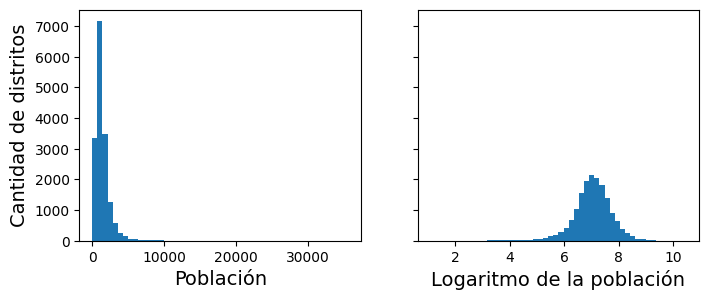

In [78]:
# código extra – esta celda genera la Figura 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
axs[0].hist(housing["population"].drop_nulls().to_numpy(), bins=50)
axs[1].hist(np.log(housing["population"].drop_nulls().to_numpy()), bins=50)
axs[0].set_xlabel("Población")
axs[1].set_xlabel("Logaritmo de la población")
axs[0].set_ylabel("Cantidad de distritos");

In [80]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(
    housing.select("housing_median_age").to_numpy(), [[35]], gamma=0.1
)

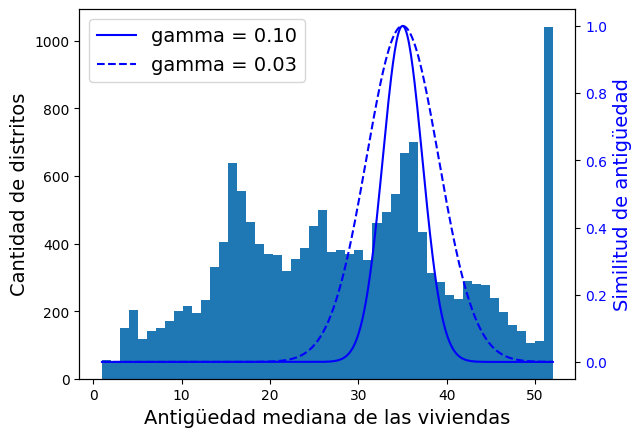

In [81]:
# código extra – esta celda genera la Figura 2–18

ages = np.linspace(
    housing["housing_median_age"].min(), housing["housing_median_age"].max(), 500
).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Antigüedad mediana de las viviendas")
ax1.set_ylabel("Cantidad de distritos")
ax1.hist(housing["housing_median_age"].drop_nulls().to_numpy(), bins=50)

ax2 = ax1.twinx()  # crear un eje gemelo que comparta el mismo eje x
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylabel("Similitud de antigüedad", color=color)

plt.legend(loc="upper left")

plt.show()

In [82]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame().to_numpy())

model = LinearRegression()
model.fit(housing.select("median_income").to_numpy(), scaled_labels)
some_new_data = housing.select("median_income").head(
    5
)  # supongamos que estos son datos nuevos

scaled_predictions = model.predict(some_new_data.to_numpy())
predictions = target_scaler.inverse_transform(scaled_predictions)

In [83]:
predictions

array([[393767.28579276],
       [392768.19727172],
       [348942.63357583],
       [281176.72603341],
       [205745.54269514]])

In [84]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing.select("median_income").to_numpy(), housing_labels.to_numpy())
predictions = model.predict(some_new_data.to_numpy())

In [85]:
predictions

array([393767.28579276, 392768.19727172, 348942.63357583, 281176.72603341,
       205745.54269514])

## Transformadores personalizados

Para crear transformadores simples:

In [86]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing.select("population").to_numpy())

In [87]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.0]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing.select("housing_median_age").to_numpy())

In [88]:
age_simil_35

array([[2.73237224e-02],
       [3.07487988e-09],
       [2.81118530e-13],
       ...,
       [2.81118530e-13],
       [2.81118530e-13],
       [2.09879105e-16]], shape=(16512, 1))

In [89]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(
    housing.select("latitude", "longitude").to_numpy()
)

In [90]:
sf_simil

array([[0.99566482],
       [0.99567518],
       [0.99655196],
       ...,
       [0.6452246 ],
       [0.6752005 ],
       [0.67616077]], shape=(16512, 1))

In [91]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1.0, 2.0], [3.0, 4.0]]))

array([[0.5 ],
       [0.75]])

In [92]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted


class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # sin *args ni **kwargs
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y es obligatorio aunque no lo usemos
        X = check_array(X)  # verifica que X sea un arreglo con valores float finitos
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # todo estimador guarda esto en fit()
        return self  # siempre devolver self

    def transform(self, X):
        check_is_fitted(self)  # busca atributos aprendidos (terminados en _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [93]:
from sklearn.cluster import KMeans


class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # siempre devolver self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Similitud con cluster {i}" for i in range(self.n_clusters)]

Agrupemos los distritos basándonos solo en la latitud y la longitud:

In [94]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
similarities = cluster_simil.fit_transform(
    housing.select("latitude", "longitude").to_numpy()
)

In [95]:
similarities[:3].round(2)

array([[0.27, 0.  , 0.  , 0.  , 0.76, 0.03, 0.87, 0.  , 0.  , 0.  ],
       [0.28, 0.  , 0.  , 0.  , 0.74, 0.03, 0.89, 0.  , 0.  , 0.  ],
       [0.26, 0.  , 0.  , 0.  , 0.74, 0.03, 0.89, 0.  , 0.  , 0.  ]])

In [97]:
housing

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,str
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,"""NEAR BAY"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,"""NEAR BAY"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,"""NEAR BAY"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,"""NEAR BAY"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,"""NEAR BAY"""
…,…,…,…,…,…,…,…,…
-121.56,39.27,28.0,2332.0,395.0,1041.0,344.0,3.7125,"""INLAND"""
-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,"""INLAND"""
-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,"""INLAND"""


In [96]:
# código extra – esta celda genera la Figura 2–19

housing_renamed = housing.rename(
    {
        "latitude": "Latitud",
        "longitude": "Longitud",
        "population": "Población",
        "median_house_value": "Valor mediano de la vivienda (ᴜsᴅ)",
    }
)
housing_renamed = housing_renamed.with_columns(
    pl.Series("Similitud máxima con cluster", similarities.max(axis=1))
)

plot_scatter(
    housing_renamed,
    "Longitud",
    "Latitud",
    grid=True,
    s=housing_renamed["Población"] / 100,
    label="Población",
    c=housing_renamed["Similitud máxima con cluster"],
    cmap="jet",
    colorbar=True,
    figsize=(10, 7),
)
plt.plot(
    cluster_simil.kmeans_.cluster_centers_[:, 1],
    cluster_simil.kmeans_.cluster_centers_[:, 0],
    linestyle="",
    color="black",
    marker="X",
    markersize=20,
    label="Centros de cluster",
)
plt.legend(loc="upper right")

plt.show()

ColumnNotFoundError: "median_house_value" not found

## Pipelines de transformación

Ahora construyamos un pipeline para preprocesar los atributos numéricos:

In [98]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("standardize", StandardScaler()),
    ]
)

In [99]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [100]:
from sklearn import set_config

set_config(display="diagram")

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [101]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.33,  1.05,  0.99, -0.8 , -0.97, -0.96, -0.97,  2.36],
       [-1.32,  1.04, -0.6 ,  2.03,  1.35,  0.85,  1.67,  2.34]])

In [103]:
df_housing_num_prepared = pl.DataFrame(
    housing_num_prepared,
    schema=list(num_pipeline.get_feature_names_out()),
)

In [104]:
df_housing_num_prepared.head(2)  # código extra

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
f64,f64,f64,f64,f64,f64,f64,f64
-1.327964,1.050099,0.98585,-0.796827,-0.965763,-0.964302,-0.973804,2.357306
-1.322969,1.040734,-0.604307,2.026566,1.35019,0.851473,1.670428,2.344717


In [105]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [106]:
num_pipeline[1]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [107]:
num_pipeline[:-1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has 

In [108]:
num_pipeline.named_steps["simpleimputer"]

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [109]:
num_pipeline.set_params(simpleimputer__strategy="median")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [110]:
from sklearn.compose import ColumnTransformer

num_attribs = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ]
)

In [115]:
from sklearn.compose import make_column_transformer


def numeric_columns(df):
    return df.select(pl.selectors.numeric()).columns


def string_columns(df):
    return df.select(pl.col(pl.String)).columns


preprocessing = make_column_transformer(
    (num_pipeline, numeric_columns),
    (cat_pipeline, string_columns),
)

In [116]:
housing_prepared = preprocessing.fit_transform(housing)

In [117]:
# código extra – muestra que podemos obtener un DataFrame si queremos
housing_prepared_fr = pl.DataFrame(
    housing_prepared,
    schema=list(preprocessing.get_feature_names_out()),
)
housing_prepared_fr.head(2)

pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1.327964,1.050099,0.98585,-0.796827,-0.965763,-0.964302,-0.973804,2.357306,0.0,0.0,0.0,1.0,0.0
-1.322969,1.040734,-0.604307,2.026566,1.35019,0.851473,1.670428,2.344717,0.0,0.0,0.0,1.0,0.0


In [118]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # nombres de atributos de salida


def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler(),
    )


log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler(),
)
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
preprocessing = ColumnTransformer(
    [
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        (
            "log",
            log_pipeline,
            [
                "total_bedrooms",
                "total_rooms",
                "population",
                "households",
                "median_income",
            ],
        ),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, string_columns),
    ],
    remainder=default_num_pipeline,
)  # queda una columna: housing_median_age

In [119]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [120]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Similitud con cluster 0',
       'geo__Similitud con cluster 1', 'geo__Similitud con cluster 2',
       'geo__Similitud con cluster 3', 'geo__Similitud con cluster 4',
       'geo__Similitud con cluster 5', 'geo__Similitud con cluster 6',
       'geo__Similitud con cluster 7', 'geo__Similitud con cluster 8',
       'geo__Similitud con cluster 9', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

# Seleccionar y entrenar un modelo

## Entrenar y evaluar sobre el conjunto de entrenamiento

In [121]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels.to_numpy())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

Probemos el pipeline completo de preprocessing sobre algunas instancias de entrenamiento:

In [122]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = redondeado al centenar más cercano

array([367300., 374600., 359000., 319200., 292000.])

Comparemos con los valores reales:

In [123]:
housing_labels.head(5).to_numpy()

array([452600., 358500., 352100., 341300., 342200.])

In [124]:
# código extra – calcula las razones de error discutidas en el libro
error_ratios = housing_predictions[:5].round(-2) / housing_labels.head(5).to_numpy() - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-18.8%, 4.5%, 2.0%, -6.5%, -14.7%


In [125]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels.to_numpy(), housing_predictions)
lin_rmse

69628.72473814597

In [126]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels.to_numpy())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [127]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels.to_numpy(), housing_predictions)
tree_rmse

0.0

## Mejor evaluación mediante cross-validation

In [128]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(
    tree_reg,
    housing,
    housing_labels.to_numpy(),
    scoring="neg_root_mean_squared_error",
    cv=10,
)

In [129]:
pl.Series("tree_rmses", tree_rmses).describe()

statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",66503.04337
"""std""",3049.595021
"""min""",63208.146847
"""25%""",64161.106398
"""50%""",65851.915768
"""75%""",69152.616327
"""max""",71977.004064


In [130]:
# código extra – calcula las estadísticas de error para el modelo lineal
lin_rmses = -cross_val_score(
    lin_reg,
    housing,
    housing_labels.to_numpy(),
    scoring="neg_root_mean_squared_error",
    cv=10,
)
pl.Series("lin_rmses", lin_rmses).describe()

statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",70705.192866
"""std""",4890.581493
"""min""",66050.489442
"""25%""",68065.090371
"""50%""",70038.330666
"""75%""",70411.493896
"""max""",83156.970571


**Advertencia:** la siguiente celda puede tardar algunos minutos en ejecutarse:

In [131]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(
    forest_reg,
    housing,
    housing_labels.to_numpy(),
    scoring="neg_root_mean_squared_error",
    cv=10,
)

In [132]:
pl.Series("forest_rmses", forest_rmses).describe()

statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",47327.917283
"""std""",2120.353226
"""min""",44296.059343
"""25%""",45157.740907
"""50%""",47659.703366
"""75%""",48574.14477
"""max""",51156.913725


Comparemos este RMSE medido con cross-validation (el "error de validación") con el RMSE medido sobre el conjunto de entrenamiento (el "error de entrenamiento"):

In [133]:
forest_reg.fit(housing, housing_labels.to_numpy())
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels.to_numpy(), housing_predictions)
forest_rmse

17544.565814894762

El error de entrenamiento es mucho más bajo que el error de validación, lo que normalmente significa que el modelo hizo overfitting sobre el conjunto de entrenamiento. Otra posible explicación sería que existe un desajuste entre los datos de entrenamiento y los de validación, pero no es el caso aquí, ya que ambos provienen del mismo dataset que mezclamos y dividimos en dos partes.

# Ajustar finamente el modelo

## Grid search

**Advertencia:** la siguiente celda puede tardar algunos minutos en ejecutarse:

In [134]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("random_forest", RandomForestRegressor(random_state=42)),
    ]
)
param_grid = [
    {
        "preprocessing__geo__n_clusters": [5, 8, 10],
        "random_forest__max_features": [4, 6, 8],
    },
    {
        "preprocessing__geo__n_clusters": [10, 15],
        "random_forest__max_features": [6, 8, 10],
    },
]
grid_search = GridSearchCV(
    full_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error"
)
grid_search.fit(housing, housing_labels.to_numpy())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity

Puede obtener la lista completa de hiperparámetros disponibles para ajustar consultando `full_pipeline.get_params().keys()`:

In [135]:
# código extra – muestra parte de la salida de get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

La mejor combinación de hiperparámetros encontrada:

In [136]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [137]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

Veamos la puntuación de cada combinación de hiperparámetros probada durante el grid search:

In [138]:
cv_res = pl.DataFrame(grid_search.cv_results_).sort("mean_test_score", descending=True)

# código extra – estas líneas solo hacen que el DataFrame se vea mejor
cv_res = cv_res.select(
    [
        "param_preprocessing__geo__n_clusters",
        "param_random_forest__max_features",
        "split0_test_score",
        "split1_test_score",
        "split2_test_score",
        "mean_test_score",
    ]
)
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res = cv_res.with_columns(
    [(-pl.col(col)).round(0).cast(pl.Int64).alias(col) for col in score_cols]
)

cv_res.head()

n_clusters,max_features,split0,split1,split2,mean_test_rmse
i64,i64,i64,i64,i64,i64
15,6,46245,43926,42404,44192
15,8,46333,44255,43159,44582
15,10,46697,44813,43652,45054
10,6,47320,45026,43774,45374
10,6,47320,45026,43774,45374


## Randomized search

In [139]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

Probar 30 combinaciones aleatorias de hiperparámetros (`n_iter` × `cv`):

**Advertencia:** la siguiente celda puede tardar algunos minutos en ejecutarse:

In [140]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=20),
}

rnd_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
)

rnd_search.fit(housing, housing_labels.to_numpy())

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....x7666cd818ec0>, 'random_forest__max_features': <scipy.stats....x766655d3a990>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [149]:
# código extra – muestra los resultados del randomized search
cv_res = pl.DataFrame(rnd_search.cv_results_).sort("mean_test_score", descending=True)
cv_res = cv_res.select(
    [
        "param_preprocessing__geo__n_clusters",
        "param_random_forest__max_features",
        "split0_test_score",
        "split1_test_score",
        "split2_test_score",
        "mean_test_score",
    ]
)
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res = cv_res.with_columns(
    [(-pl.col(col)).round(0).cast(pl.Int64).alias(col) for col in score_cols]
)
cv_res.head()

n_clusters,max_features,split0,split1,split2,mean_test_rmse
i64,i64,i64,i64,i64,i64
45,9,44595,42167,41261,42675
32,7,44561,42348,41527,42812
41,16,45101,43004,41610,43238
42,4,45306,42570,41897,43258
23,8,45531,43090,41901,43507


## Analizar los mejores modelos y sus errores

In [150]:
final_model = rnd_search.best_estimator_  # incluye preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.07, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.18, 0.01, 0.01, 0.02,
       0.01, 0.  , 0.01, 0.01, 0.02, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01,
       0.01, 0.02, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.  , 0.02, 0.02, 0.02, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.04, 0.01, 0.01, 0.01, 0.01, 0.  , 0.07,
       0.  , 0.  , 0.  , 0.01])

In [145]:
sorted(
    zip(feature_importances, final_model["preprocessing"].get_feature_names_out()),
    reverse=True,
)

[(np.float64(0.17880238131149134), 'log__median_income'),
 (np.float64(0.07381749533772475), 'bedrooms__ratio'),
 (np.float64(0.07267469411184849), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.05698858473027031), 'rooms_per_house__ratio'),
 (np.float64(0.05089874665251742), 'people_per_house__ratio'),
 (np.float64(0.0376693387226664), 'geo__Similitud con cluster 40'),
 (np.float64(0.02415140988126297), 'geo__Similitud con cluster 29'),
 (np.float64(0.023056013193885165), 'geo__Similitud con cluster 17'),
 (np.float64(0.022163413185462433), 'geo__Similitud con cluster 2'),
 (np.float64(0.022162257131750136), 'geo__Similitud con cluster 7'),
 (np.float64(0.02042285785093997), 'geo__Similitud con cluster 15'),
 (np.float64(0.01796973985448446), 'geo__Similitud con cluster 11'),
 (np.float64(0.01644197852121045), 'geo__Similitud con cluster 22'),
 (np.float64(0.015231042485248592), 'geo__Similitud con cluster 31'),
 (np.float64(0.015208213770897637), 'geo__Similitud con cluster 30'),
 (n

## Evaluar el sistema en el conjunto de prueba

In [146]:
X_test = strat_test_set.drop("median_house_value")
y_test = strat_test_set["median_house_value"].clone()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test.to_numpy(), final_predictions)
print(final_rmse)

40623.466919823426


Podemos calcular un intervalo de confianza del 95% para el RMSE de prueba usando la función `bootstrap()` de SciPy:

In [147]:
from scipy.stats import bootstrap


def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))


confidence = 0.95
squared_errors = (final_predictions - y_test.to_numpy()) ** 2
boot_result = bootstrap(
    [squared_errors], rmse, confidence_level=confidence, random_state=42
)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [148]:
print(f"IC del 95% para el RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

IC del 95% para el RMSE: (38814.7962, 42771.7059)


## Persistencia del modelo con joblib

Guardar el modelo final:

In [151]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

Ahora puede desplegar este modelo en producción. Por ejemplo, el siguiente código podría ser un script que corra en producción:

In [152]:
import joblib
final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.head(5)  # supongamos que estos son distritos nuevos
predictions = final_model_reloaded.predict(new_data)

In [153]:
predictions

array([436069.06, 367317.03, 390465.16, 330489.  , 312521.  ])

Podría usar `pickle` en su lugar, pero `joblib` es más eficiente.